# Exam Score Prediction Project

## Importing libraries & Reading Data

In [364]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [366]:
# reading csv
df = pd.read_csv('student_habits_performance.csv')
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## EDA

In [369]:
df.shape

(1000, 16)

In [371]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [373]:
# checking for duplicates
df.duplicated().sum()

0

In [374]:
# checking for missing values
df.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [375]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [376]:
df.describe(include="object")

,student_id,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,1000,1000,1000,1000,909,1000,1000
unique,1000,3,2,3,3,3,2
top,S1000,Female,No,Fair,High School,Good,No
freq,1,481,785,437,392,447,682


In [377]:
# inspecting unique value counts for each categorical feature
categorical_columns = ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']
for column in categorical_columns:
    print(df[column].value_counts(), '\n')

gender
Female    481
Male      477
Other      42
Name: count, dtype: int64 

part_time_job
No     785
Yes    215
Name: count, dtype: int64 

diet_quality
Fair    437
Good    378
Poor    185
Name: count, dtype: int64 

parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64 

internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64 

extracurricular_participation
No     682
Yes    318
Name: count, dtype: int64 



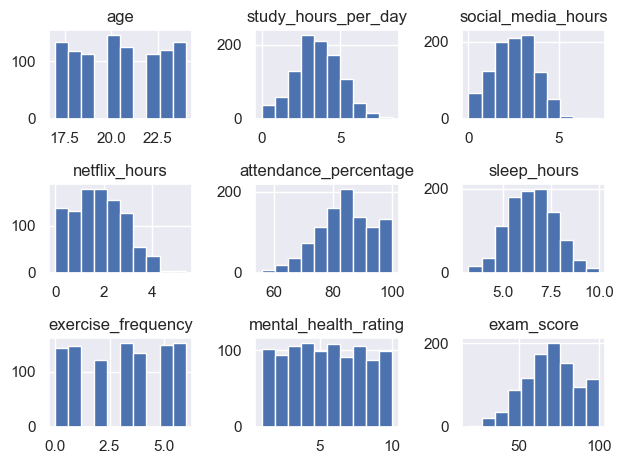

In [378]:
# plotting numerical features distributions
df.hist()
plt.tight_layout()
plt.show()

In [379]:
# checking skewness
df.skew(numeric_only=True)

age                      0.008437
study_hours_per_day      0.054253
social_media_hours       0.119805
netflix_hours            0.237154
attendance_percentage   -0.237810
sleep_hours              0.091484
exercise_frequency      -0.031923
mental_health_rating     0.037811
exam_score              -0.156351
dtype: float64

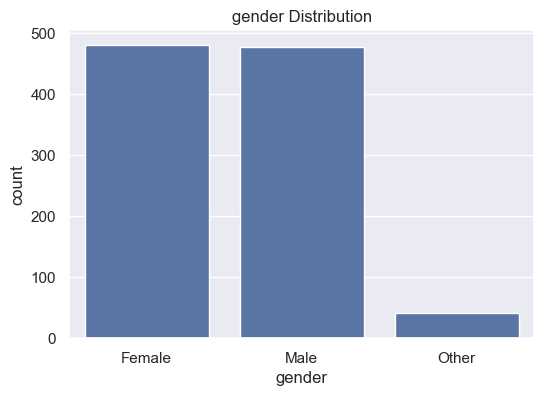

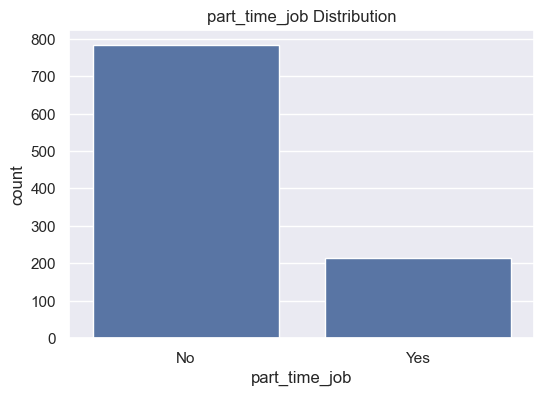

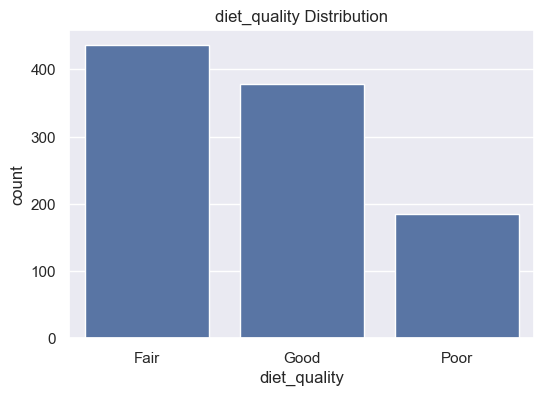

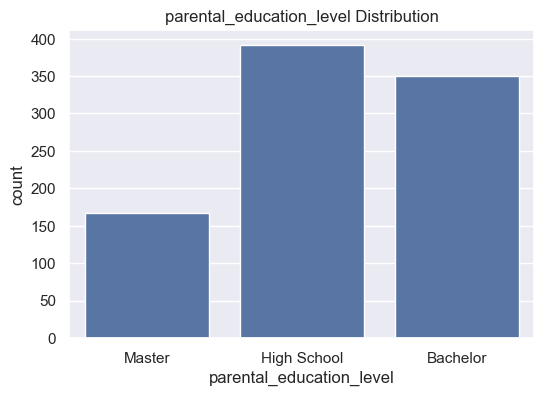

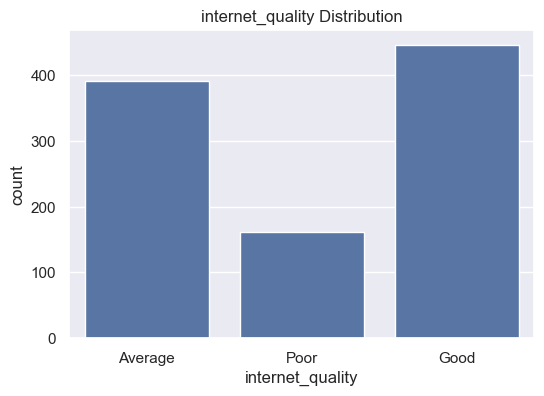

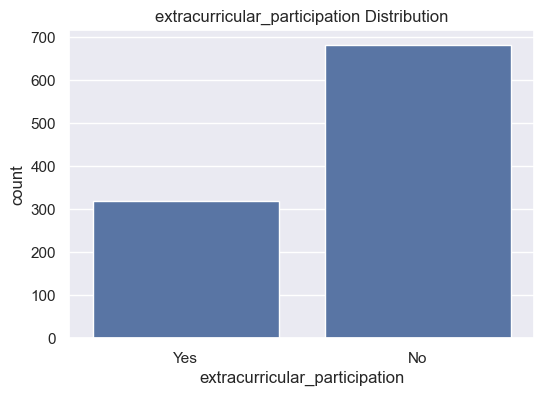

In [380]:
# plotting bar plots for categorical columns distributions
for column in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=column)
    plt.title(f'{column} Distribution')

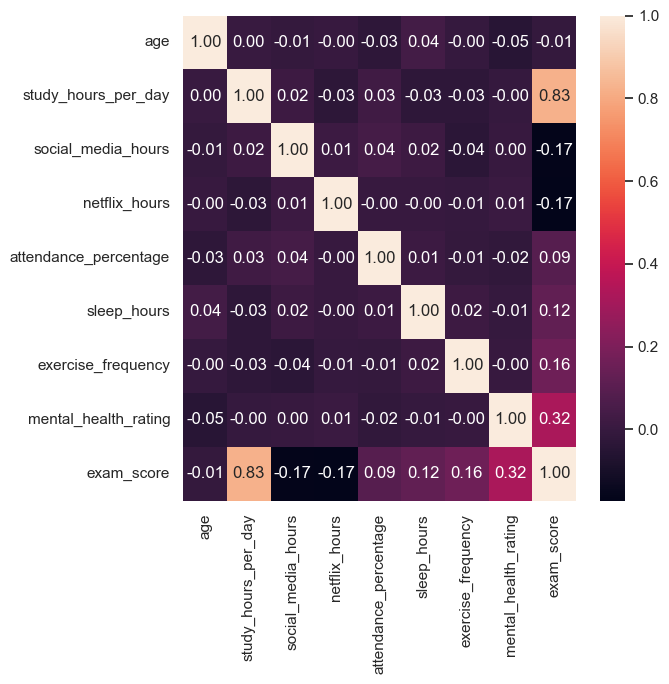

In [381]:
# checking for correlation
plt.figure(figsize=(7,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f')
plt.tight_layout()
plt.show()

## Model Building

In [383]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [389]:
# splitting data to features and target
X = df.drop(columns=['student_id', 'exam_score'], axis=1)
y = df['exam_score']

In [390]:
# splitting data to training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [391]:
# getting numerical features and categorical features for respective preprocessing
numerical_columns = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = X_train.select_dtypes(include=['object']).columns.tolist()

In [416]:
# constructing pipelines for numerical and categorical columns
numerical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(drop='first', sparse_output=False).set_output(transform='pandas'))
])

# composing column transformer for feature preprocessing
preprocessor = ColumnTransformer([
    ('scaling', numerical_pipeline, numerical_columns),
    ('encoding', categorical_pipeline, categorical_columns)
])

In [418]:
# models to select best performing one
models = {
    'linear regression': LinearRegression(),
    'lasso regression': Lasso(),
    'ridge regression': Ridge(),
    'random forest regressor': RandomForestRegressor(),
}

In [420]:
# parameter grid for each model
parameters = {
    'linear regression': {
    },
    'lasso regression': {
        'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
    },
    'ridge regression': {
        'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
    },
    'random forest regressor': {
        'model__n_estimators': [100, 200, 500],
        'model__max_depth': [10, 20, 30],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2']
        
    }
}

In [422]:
# constructing pipelines for each model
pipelines = {
    name: Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])
    for name, model in models.items()
}

In [424]:
# using GridSearchCV with cross-validation to train and select the model with the best performance
best_models = {}
for model in models.keys():
    gs = GridSearchCV(estimator=pipelines[model], param_grid=parameters[model], scoring='r2', cv=5, n_jobs=-1)
    gs.fit(X_train, y_train)
    best_models[model] = gs

In [425]:
# best hypertuning for each model along with best score
for model, gs in best_models.items():
    print(model, gs.best_params_, gs.best_score_, '\n')

linear regression {} 0.895583758425342 

lasso regression {'model__alpha': 0.1} 0.8961297257907447 

ridge regression {'model__alpha': 1} 0.8956029450569929 

random forest regressor {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200} 0.7868575357367482 



In [426]:
# best model with its score
best_score = -1
for model, gs in best_models.items():
    if gs.best_score_ > best_score:
        best_score = gs.best_score_
        best_model = gs.best_estimator_
        best_model_name = model
print(best_model_name, best_score)

lasso regression 0.8961297257907447


In [427]:
# model performance score on testing data
y_pred = best_model.predict(X_test)
test_score = r2_score(y_test, y_pred)
test_score

0.8981880829852785

In [428]:
# saving model
joblib.dump(best_model, 'best_model.pkl')

['best_model.pkl']